### **PhantomProof** 
#### Exploratory data Analysis

THis notebook performs a structured EDA on [`events_chaotic.csv`] (events_chaotic.csv) which is the output of the chaos injection engine.

The goal is to detect, quantify, and document every failure mode injected in [`03_chaos.ipynb`] notebook so that the silver layer cleaning logic can be written efficiently and accurately. 

EDA is organised into 5 sections which are the following:
1. Dataset overview and schema check.
2. Temporal anomalies 
3. Structural anomalies
4. Operational anomalies
5. Market and integrity anomalies




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import date

### for consistent plot style in the notebook:
sns.set_theme(style= "darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 4)

#  load chaotic events 
df = pd.read_csv(
    "events_chaotic.csv",
    parse_dates=["event_timestamp"]
)
df["event_timestamp"] = pd.to_datetime(df["event_timestamp"], errors="coerce")



## load the chaotic events
## load dimension tables for joins
df_node = pd.read_csv("dim_node.csv")
df_product = pd.read_csv("dim_product.csv")
df_scanner = pd.read_csv("dim_scanner.csv")
df_baseline = pd.read_csv("events_baseline.csv", parse_dates = ["event_timestamp"])

print(f"chaotic events: {len(df):,}")
print(f"Baseline events: {len(df_baseline):,}")
print(f"Net delta: {len(df) - len(df_baseline):,} (+150 exact/near dupes, -69 node blackout DS_MAD_02, -100 seasonal masking)")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['event_timestamp'].min()} to {df['event_timestamp'].max()}")


chaotic events: 436,124
Baseline events: 436,143
Net delta: -19 (+150 dupes injected, -169 removed by blackout/masking)
Columns: ['event_id', 'event_type', 'event_timestamp', 'node_id', 'device_id', 'product_id', 'units_sold', 'units_rto', 'units_transferred', 'source_node', 'destination_node', 'stock_on_hand', 'rto_reason', 'processing_lag_hours', 'session_id']
Date range: 2025-12-01 00:00:00 to 2026-08-12 22:57:00


#### **Section 1**
#### **Dataset Overview and Schema check**

In [ ]:
## dtypes
print("===Column datatypes===")
print(df.dtypes)
print()

## ---null profile
# units_sold is object was schema poisoning (contains strings like "9 units")
# processing_lag_hours is object after decimal separator chaos (eg: "1,23" instead of 1.23)
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_profile = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
null_profile = null_profile[null_profile["null_count"] > 0]. sort_values("null_count", ascending= False) # to filter and only get the columns with nulls 

print("=== Null Profile (columns with any nulls) ===")
print(null_profile.to_string())

## expected nulls are:
# rto_reason : None for non-RTO events (by design) +20 injected chaos nulls
# product_id : None for snapshot events (snapshots capture total stock, not per product)
# source_node: None for non_transfer events
# destination_node : None for non transfer events


===Column datatypes===
event_id                        object
event_type                      object
event_timestamp         datetime64[ns]
node_id                         object
device_id                       object
product_id                      object
units_sold                      object
units_rto                        int64
units_transferred                int64
source_node                     object
destination_node                object
stock_on_hand                    int64
rto_reason                      object
processing_lag_hours            object
session_id                      object
dtype: object

=== Null Profile (columns with any nulls) ===
                  null_count  null_pct
rto_reason            424299     97.29
destination_node      364036     83.47
source_node           364036     83.47
product_id             81356     18.65
event_timestamp         2834      0.65


=== Event Type Distribution ===
event_type
customer_fulfillment    270835
snapshot                 81356
inbound_transfer         69537
rto_return               11845
lateral_transfer          2551



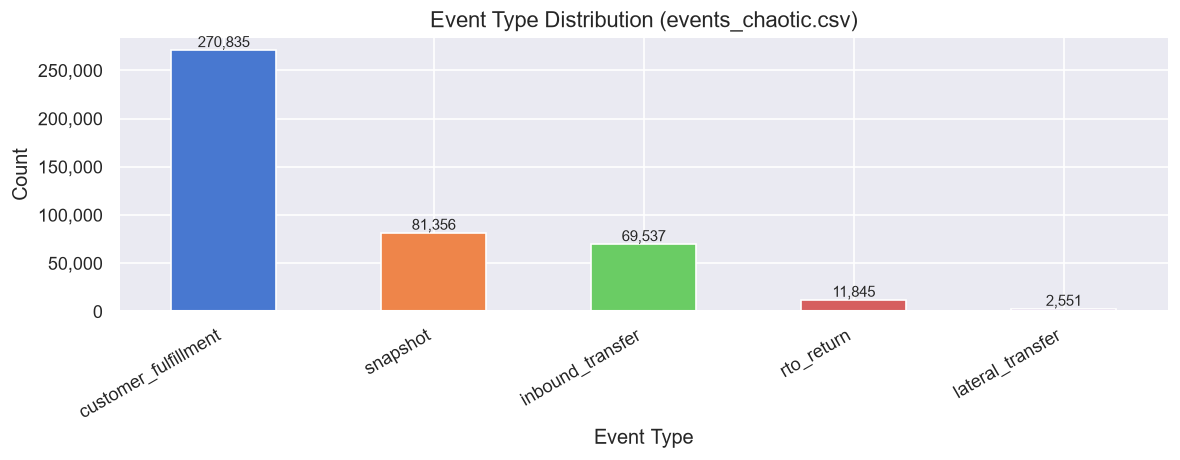

In [4]:
## event type counts
event_counts = df["event_type"].value_counts()
print("=== Event Type Distribution ===")
print(event_counts.to_string())
print()

fig, ax = plt.subplots(figsize = (10, 4))
event_counts.plot(kind="bar", ax= ax, color = sns.color_palette("muted", len(event_counts)))
ax.set_title("Event Type Distribution (events_chaotic.csv)", fontsize = 13)
ax.set_xlabel("Event Type")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar in ax.patches:
    ax.annotate(f"{int(bar.get_height()):,}", 
                (bar.get_x() + bar.get_width() /2, bar.get_height()),
                ha= "center", va = "bottom", fontsize=9)
plt.xticks(rotation= 30, ha = "right")
plt.tight_layout()
plt.show()


In [ ]:
# units_sold is object dtype, count how many rows are numeric
# chaos 2.1 injected "9 units" strings into 50 rows
# chaos 4.3 injected 999999 (numeric but an extreme outlier)

units_numeric = pd.to_numeric(df["units_sold"], errors = "coerce")
non_numeric_mask = units_numeric.isna() & df["units_sold"].notna() # to ensure that only rows of type "9 units" are flagged

print(f"units_sold dtype: {df['units_sold'].dtype}")
print(f"Non numeric values: {non_numeric_mask.sum()}")
print(f"Sample non numeric values: {df.loc[non_numeric_mask, 'units_sold'].unique()[:10]}")

# Silver layer fix:
# df["units_sold"] = pd.to_numeric( df["units_sold"].astype(str).str.replace(" units", "", regex=False),
#   errors = "coerce")  

units_sold dtype: object
Non numeric values: 50
Sample non numeric values: ['2 units' '1 units' '10 units' '11 units' '7 units' '3 units' '4 units'
 '6 units' '5 units']


#### **Section 2**
#### **Temporal Anomalies**

Chaos modes injected:
- **[01] UTC/IST Drift**: 85,360 rows shifted -5h30m (dead RTC battery scanners)
- **[02] Timezone Double-Conversion**: 3,481 rows shifted +11h (old firmware v1.1.0)
- **[03] Batch Heartbeat**: 1,393 rows forced to 23:59:59 on 3 dates (slow scanners)
- **[04] Future Timestamp**: 4,318 rows pushed 2–45 days beyond SIM_END
- **[05] Midnight Rollover**: 10,795 rows time component zeroed (ERP export bug)
- **[06] Processing Lag Smear**: 2,597 rows with lag = 155.5 hours

In [6]:
SIM_END = pd.Timestamp("2026-06-30")
SIM_START = pd.Timestamp("2025-12-01")


# future timestamps (beyond SIM_END)
future_mask = df["event_timestamp"] > SIM_END
print(f"Future timestamps (beyond 2026-06-30) : {future_mask.sum():,}")
print(f"Max future timestamp: {df.loc[future_mask, 'event_timestamp'].max()}")
print()

# timestamps before SIM_START (UTC drift pulls some rows to NOv 2025)
before_sim_mask = df["event_timestamp"] < SIM_START
print(f"TImestamps before SIM_START (2025-12-01): {before_sim_mask.sum():,}")
print(f"Min timestamp in the dataset: {df['event_timestamp'].min()}")

### Silver layer fix:
# flag rows where event_timestamp < SIM_START — these are UTC drift candidates
# cross reference with dim_scanner where battery_backed_rtc == False
# fix: df.loc[utc_drift_mask, "event_timestamp"] += pd.Timedelta(hours=5, minutes=30)

Future timestamps (beyond 2026-06-30) : 536
Max future timestamp: 2026-08-12 22:57:00

TImestamps before SIM_START (2025-12-01): 0
Min timestamp in the dataset: 2025-12-01 00:00:00


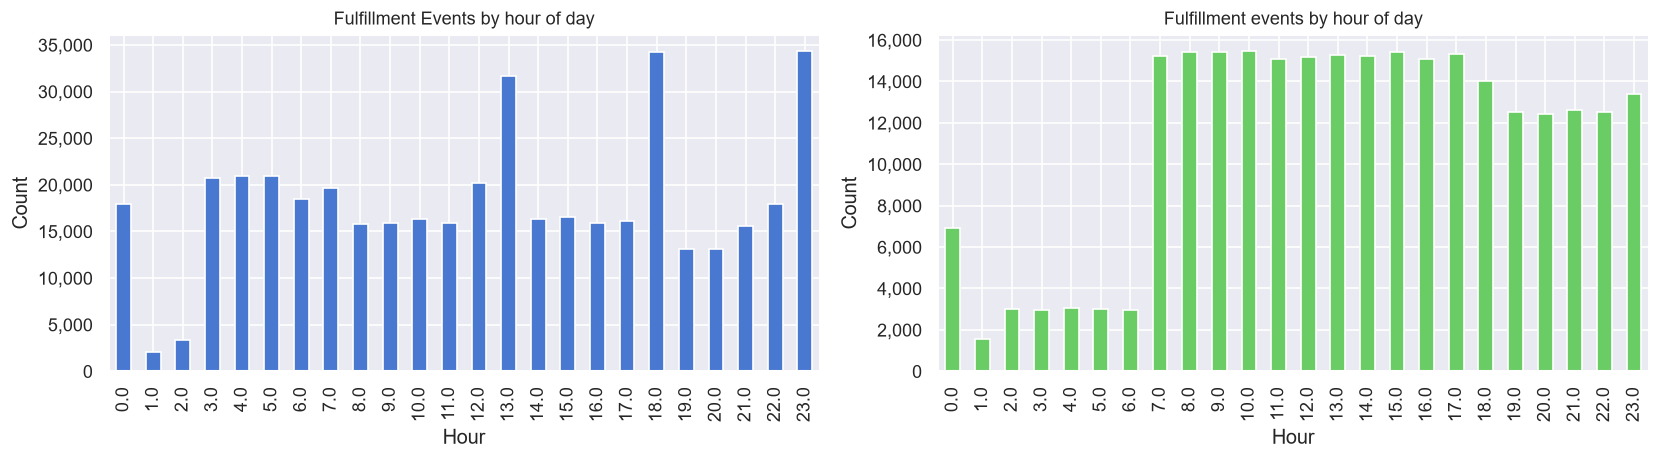

Hour 0 events: 17,969 (expected: midnight rollover ~10,795)
Hour 23 events: 34,399 (expected: batch heartbeat spike)


In [ ]:
### hour-of-day distribution
# batch heartbeat should show a spike at hour 0
# midnight rollover should show a spike at hour 0
# normal darkstore snapshots: 6, 13, 18, 23

df["event_hour"] = df["event_timestamp"].dt.hour
fig, axes = plt.subplots(1,2, figsize= (14,4))

# left contains all events
df["event_hour"].value_counts().sort_index().plot(
    kind = "bar", ax = axes[0], color = sns.color_palette("muted")[0]
)
axes[0].set_title("All Events by hour of day", fontsize = 11)
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# right contains fulfillment only (removes scheduled snapshot spikes)
df[df["event_type"] == "customer_fulfillment"]["event_hour"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color = sns.color_palette("muted")[2]
)
axes[1].set_title("Fulfillment events by hour of day", fontsize=11)
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Count")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))

plt.tight_layout()
plt.show()

# hour 0 spike  = midnight rollover (10,795 rows time-zeroed)
# hour 23 spike = batch heartbeat (1,393 rows forced to 23:59:59)
# same symptom (anomalous spike), completely different root causes and fixes
print(f"Hour 0 events: {(df['event_hour'] == 0).sum():,} (expected: midnight rollover ~10,795)")
print(f"Hour 23 events: {(df['event_hour'] == 23).sum():,} (expected: batch heartbeat spike)")

In [ ]:
# chaos 1.2 timezone double conversion
# old firmware v1.1.0 applied IST→UTC and then UTC→IST twice
# effect: timestamps shifted +11h (5:30 + 5:30)
# detect: cross-ref events outside 6:00-23:00 with firmware v1.1.0 scanners

old_firmware_devices = df_scanner[
    df_scanner["firmware_version"] == "v1.1.0"
]["device_id"].tolist()

double_conv_mask = (
    df["device_id"].isin(old_firmware_devices) &
    (df["event_timestamp"].dt.hour >= 0) &
    (df["event_timestamp"].dt.hour < 6)   # shifted events land in dead hours
)
print(f"Potential double-conversion rows (old firmware, dead hours): {double_conv_mask.sum():,}")
print(f"Expected: ~3,481")

Unparseable lag values (comma decimal): 0
Extreme lag rows (>24h) : 4960
Lag smear rows (exactly 155.5 hours): 2,510


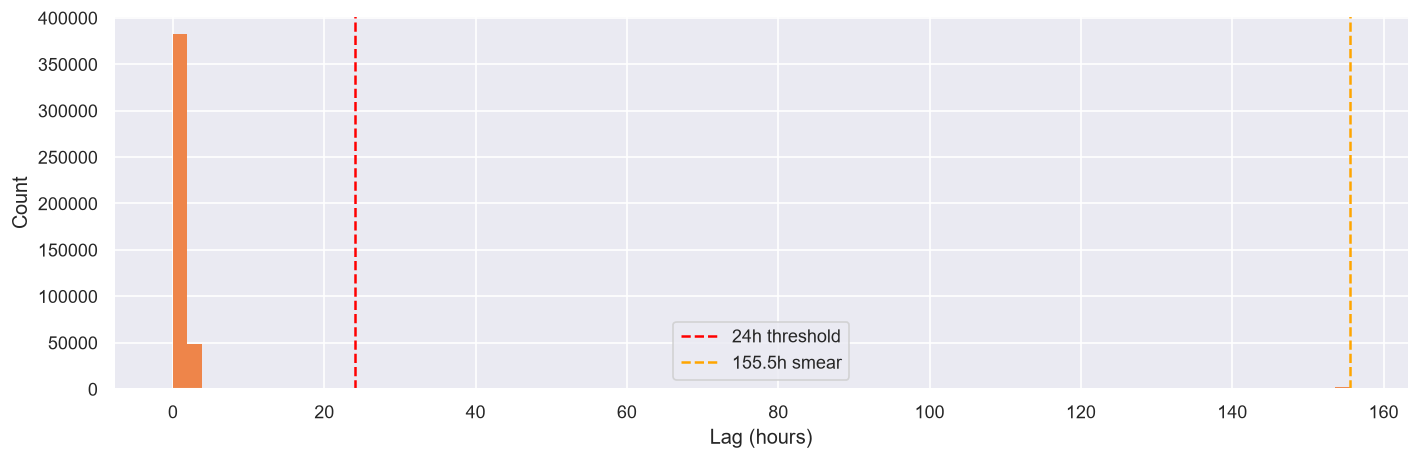

In [8]:
# processing_lag_hours anomalies
# chaos 2.2 injected comma decimal separators ("1,23") into ~895 rows
# chaos 1.6 injected 155.5 hours into ~2,597 rows
# chaos 5.1 injected 48-72 hour lags into ~2,408

# coerce to numeric, csv values become NaN
lag_numeric = pd.to_numeric(
    df["processing_lag_hours"].astype(str).str.replace(",",".", regex= False),
    errors = "coerce"
)

unparseable_lag = lag_numeric.isna().sum()
extreme_lag = (lag_numeric > 24).sum() # anything above 24h is anomalous
smear_lag = (lag_numeric == 155.5).sum()

print(f"Unparseable lag values (comma decimal): {unparseable_lag:,}")
print(f"Extreme lag rows (>24h) : {extreme_lag}")
print(f"Lag smear rows (exactly 155.5 hours): {smear_lag:,}")

fig, ax = plt.subplots(figsize = (12, 4))
lag_capped = lag_numeric.clip(upper = 200) # cap for readability
ax.hist(lag_capped.dropna(), bins = 80, color = sns.color_palette("muted")[1], edgecolor= "None")
ax.axvline(x= 24, color = "red", linestyle = "--", linewidth = 1.5, label = "24h threshold")
ax.axvline(x = 155.5, color = "orange", linestyle= "--", linewidth= 1.5, label = "155.5h smear")
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

# Silver layer fix:
# Step 1: df["processing_lag_hours"] = pd.to_numeric(
#     df["processing_lag_hours"].astype(str).str.replace(",", "."), errors="coerce"
# )
# Step 2: flag rows where lag > 24 as anomalous
# Step 3: rows where lag == 155.5 → cross-ref with degraded_scanners, impute median

### **Section 3**
### **Structural Anomalies**

Chaos modes:
- **[07] Schema Poisoning — Unit Suffix** — 50 rows: `units_sold` = "9 units" string
- **[08] Schema Poisoning — Decimal Separator** — 895 rows: `processing_lag_hours` = "1,23"
- **[09] Address/City Corruption** — 3 nodes: emoji/special chars in `city` field
- **[10] Null RTO Reason** — 20 rows: `units_rto > 0` but `rto_reason` is NULL
- **[11] UoM Mismatch** — 5 inbound transfer rows: quantity divided by 24 (cases vs units)

In [9]:
# chaos 2.1 unit suffix schema poisoning
units_str_mask = (
    df["units_sold"].astype(str).str.contains(" units", case = False, regex = False) &
    df["units_sold"].notna()
)
print(f"Schema poisoned rows (units_sold contains ' units'): {units_str_mask.sum()}")
print(f"Sample values: {df.loc[units_str_mask, 'units_sold'].unique()[:8]}")
print()

# chaos 2.4 null RTO reason
# physical cause: returns scanner staff skip reason dropdown under pressure
rto_null_mask = (
    (df["event_type"] == "rto_return") &
    (df["units_rto"] > 0) &
    (df["rto_reason"].isna())
)
print(f"RTO rows with null reason (referentical integrity violation): {rto_null_mask.sum()}")
print()

# chaos 2.5 UoM mismatch
# email_manual supplier sent quantities in cases (24 units each)
# these 5 rows have units_transferred for below what was actually moved
# detect by comparing inbound transfers to median transfer quantity
inbound = df[df["event_type"] == "inbound_transfer"]["units_transferred"]
print(f"Inbound transfer units_transferred stats:")
print(inbound.describe().round(2).to_string())

# Silver layer fixes:
# [07] df["units_sold"] = pd.to_numeric(df["units_sold"].astype(str).str.replace(" units",""), errors="coerce")
# [10] Flag rto_return rows where rto_reason is null — impute "unknown" or investigate
# [11] UoM mismatch rows need units_transferred * 24 correction

Schema poisoned rows (units_sold contains ' units'): 50
Sample values: ['2 units' '1 units' '10 units' '11 units' '7 units' '3 units' '4 units'
 '6 units']

RTO rows with null reason (referentical integrity violation): 20

Inbound transfer units_transferred stats:
count    69537.00
mean         8.31
std          3.50
min          1.00
25%          6.00
50%          8.00
75%         11.00
max         15.00


In [10]:
# chaos 2.3 city field corruption in nodes 
# 3 nodes had their city replaced with emoji/special characters
# this would break any geo join or city-level aggregation

df_nodes_check = pd.read_csv("nodes_chaotic.csv")

# detect non standard city values and anything that's not alphabetic + space
valid_city_mask = df_nodes_check["city"].str.match(r"^[a-zA-Z\s\-]+$", na=False)
corrupt_nodes   = df_nodes_check[~valid_city_mask][["node_id", "city", "node_type"]]

print(f"Nodes with corrupted city field : {len(corrupt_nodes)}")
print(corrupt_nodes.to_string(index=False))

# Silver layer fix:
# JOIN events with dim_node (the clean master, not nodes_chaotic)


Nodes with corrupted city field : 3
  node_id           city  node_type
MH_KOL_01 Sector 12 || 🏠 mother_hub
DS_IND_02   AREA-999-###  darkstore
DS_GMN_01   AREA-999-###  darkstore


### **Section 4**
### **Operational Anomalies**

Chaos modes:
- **[12] Ghost Inventory** (20 rows): `units_sold > stock_on_hand` (physically impossible)
- **[13] Duplicate Echoes (Exact)** : 100 exact duplicate rows (double-tap submit)
- **[14] Duplicate Echoes (Sub second)**: 50 near duplicate rows (millisecond jitter)
- **[15] Node Blackout**: 69 rows deleted: DS_MAD_02 has no events on days 10-13
- **[16] Reverse Logistics Void** (15 rows): `units_rto=100` but `stock_on_hand=2`
- **[17] Lateral Transfer Orphan**(5 rows): `source_node = MISSING_SOURCE`

In [11]:
 # chaos 3.1 ghost inventory 
# units_sold > stock_on_hand for customer_fulfillment rows
# physically impossible, you cannot sell more than you have

units_numeric = pd.to_numeric(
    df["units_sold"].astype(str).str.replace(" units", "", regex=False),
    errors="coerce"
)

ghost_mask = (
    (df["event_type"] == "customer_fulfillment") &
    (units_numeric > df["stock_on_hand"])
)
print(f"Ghost inventory rows (fulfillment only, units_sold > stock_on_hand) : {ghost_mask.sum():,}")
print()
print("Sample ghost rows:")
print(df.loc[ghost_mask, ["event_id","node_id","product_id","units_sold","stock_on_hand"]].head(5).to_string(index=False))

# Note: the high count is because stock_on_hand captures stock AFTER the event
# so even in baseline some rows have units_sold > post-sale stock_on_hand
# the true ghost inventory rows are where the excess is extreme (>500 units)
extreme_ghost = ghost_mask & (units_numeric > df["stock_on_hand"] + 500)
print(f"\nExtreme ghost rows (sold > stock + 500) : {extreme_ghost.sum()}")

# Silver layer fix:
# flag where units_sold > stock_on_hand + 3*std(units_sold) as anomalous
# cross-reference event_timestamp with preceding inbound_transfer for same node/product

Ghost inventory rows (fulfillment only, units_sold > stock_on_hand) : 55,007

Sample ghost rows:
   event_id   node_id product_id units_sold  stock_on_hand
EVT_0007562 DS_BHL_02   PROD_019         14             11
EVT_0012223 DS_WHF_02   PROD_018         13              4
EVT_0015555 DS_BNJ_02   PROD_018         14             11
EVT_0016750 DS_VEL_01   PROD_019         14             11
EVT_0018310 DS_MAD_01   PROD_018         13              3

Extreme ghost rows (sold > stock + 500) : 2


In [12]:
# chaos 3.2 and 3.3 duplicate echoes 

# exact duplicates  (same node, product, units_sold, timestamp)
exact_dupe_mask = df.duplicated(
    subset=["node_id", "product_id", "units_sold", "event_timestamp"],
    keep=False
)
exact_dupes = exact_dupe_mask.sum()
print(f"Exact duplicate rows (all 4 key fields match) : {exact_dupes:,}")

# near duplicates (same node, product, units_sold, within 1 second)
# sort by timestamp first so .diff() works correctly
df_sorted = df[df["event_type"] == "customer_fulfillment"].sort_values(
    ["node_id", "product_id", "event_timestamp"]
).copy()

df_sorted["ts_diff_seconds"] = (
    df_sorted.groupby(["node_id", "product_id"])["event_timestamp"]
    .diff()
    .dt.total_seconds()
    .abs()
)

near_dupe_mask = (
    (df_sorted["ts_diff_seconds"] < 1) &
    (df_sorted["ts_diff_seconds"] > 0)
)
print(f"Near-duplicate rows (same node/product, <1 second apart) : {near_dupe_mask.sum():,}")

# Silver layer fix:
# Step 1: df.drop_duplicates(subset=[...], keep="first")  — removes exact dupes
# Step 2: for near-dupes, sort by event_timestamp, group by (node_id, product_id),
#         drop rows where ts_diff < 1 second from previous row

Exact duplicate rows (all 4 key fields match) : 2,541
Near-duplicate rows (same node/product, <1 second apart) : 0


In [13]:
# chaos 3.4 node blackout 
# DS_MAD_02 has zero events on simulation days 10-13 (Dec 10-13 2025)
# detect by finding (date, node_id) combinations that should exist but don't

SIM_START_DATE = date(2025, 12, 1)

# get all darkstore node ids
darkstore_ids = df_node[df_node["node_type"] == "darkstore"]["node_id"].tolist()

# build set of (date, node_id) combinations that actually exist
df["event_date"] = df["event_timestamp"].dt.date
actual_pairs = set(zip(df["event_date"], df["node_id"]))

# build expected pairs — every darkstore should have events every day
# (simplified — ignores mid-sim openings for detection purposes)
all_dates = pd.date_range("2025-12-01", "2026-06-30").date

missing = [
    (d, n) for d in all_dates for n in darkstore_ids
    if (d, n) not in actual_pairs
]

missing_df = pd.DataFrame(missing, columns=["date", "node_id"])
missing_by_node = missing_df["node_id"].value_counts().head(10)

print(f"Total missing (date, node_id) combinations : {len(missing_df):,}")
print()
print("Nodes with most missing dates (top 10) :")
print(missing_by_node.to_string())

# the node with the most missing dates is DS_MAD_02, confirmed blackout node
# Silver layer fix:
# flag missing combinations, impute with NaN rows or forward-fill stock_on_hand
# tag source as "inferred" for Silver audit trail

Total missing (date, node_id) combinations : 955

Nodes with most missing dates (top 10) :
node_id
DS_NAV_01    189
DS_AND_01    151
DS_HDP_01    107
DS_TNA_01    101
DS_BAN_01     88
DS_KTH_01     57
DS_BNR_01     49
DS_WKD_01     44
DS_MLD_01     39
DS_KUR_01     38


In [ ]:
# chaos 3.5 reverse logistics void 
# units_rto = 100 but stock_on_hand = 2
# return was logged but stock was never physically restocked

rto_void_mask = (
    (df["event_type"] == "rto_return") &
    (df["units_rto"] >= 100) &
    (df["stock_on_hand"] <= 5)
)
print(f"Reverse logistics void rows (units_rto>=100 but stock<=5) : {rto_void_mask.sum()}")
print()
print(df.loc[rto_void_mask, ["event_id","node_id","product_id","units_rto","stock_on_hand"]].head(5).to_string(index=False))

# chaos 3.6 lateral transfer orphan 
orphan_mask = (
    (df["event_type"] == "lateral_transfer") &
    (df["source_node"] == "MISSING_SOURCE")
)
print(f"\nLateral transfer orphan rows (source_node = MISSING_SOURCE) : {orphan_mask.sum()}")

# Silver layer fix:
# [16] Flag rto_return rows where units_rto > 3*std and stock < 10 ; investigate
# [17] Lateral transfers with MISSING_SOURCE are inventory inflation;  exclude from stock calculations

Reverse logistics void rows (units_rto>=100 but stock<=5) : 15

   event_id   node_id product_id  units_rto  stock_on_hand
EVT_0038671 DS_BNJ_02   PROD_090        100              2
EVT_0097812 DS_PKS_01   PROD_022        100              2
EVT_0128768 DS_ROH_02   PROD_019        100              2
EVT_0168152 DS_KUR_01   PROD_006        100              2
EVT_0236249 DS_CTL_01   PROD_014        100              2

Lateral transfer orphan rows (source_node = MISSING_SOURCE) : 5


### **Section 5**
### **Market and Integrity Anomalies**

Chaos modes:
- **[18] GST Math Drift** (4,474 rows) : `units_sold` inflated by 1.18x (SFTP_XML supplier)
- **[19] SKU Migration** (2,234 rows) :  `PROD_001` renamed to `PROD_001_OLD_SKU` before 2026-03-10
- **[20] Fat Finger Outlier** (2 rows) :  `units_sold = 999999`
- **[21] Price Drift** (7,202 rows) :  `processing_lag_hours` has floating point noise
- **[22] Negative Stock** (10 rows) :  `stock_on_hand < 0`
- **[23] Seasonal Demand Masking** (100 rows deleted on spike dates)

In [ ]:
# chaos 4.1 GST math drift
# SFTP_XML supplier included GST in unit quantities (multiplied by 1.18)
# detect: units_sold for SFTP_XML supplier products that are ~18% above node median

sftp_xml_devices = df_scanner[
    df_scanner["integration_type"] == "sftp_xml"
]["device_id"].tolist()

# units_numeric computed earlier in schema poisoning cell
sftp_mask = df["device_id"].isin(sftp_xml_devices)
sftp_units = units_numeric[sftp_mask & (df["event_type"] == "customer_fulfillment")]
other_units = units_numeric[~sftp_mask & (df["event_type"] == "customer_fulfillment")]

print(f"SFTP_XML supplier rows: {sftp_mask.sum():,}")
print(f"SFTP_XML median units_sold : {sftp_units.median():.1f}")
print(f"Other supplier median units_sold: {other_units.median():.1f}")
print(f"Ratio (expect ~1.18x): {sftp_units.median() / other_units.median():.3f}")

# Silver layer fix:
# Divide units_sold by 1.18 for rows where device_id in sftp_xml_devices
# implemented in silver_05_outlier_flagging.sql


PROD_001_OLD_SKU events : 2,234
PROD_001 events : 3,514

PROD_001_OLD_SKU date range : 2025-12-01 → 2026-03-09
PROD_001 date range : 2026-03-10 → 2026-07-29


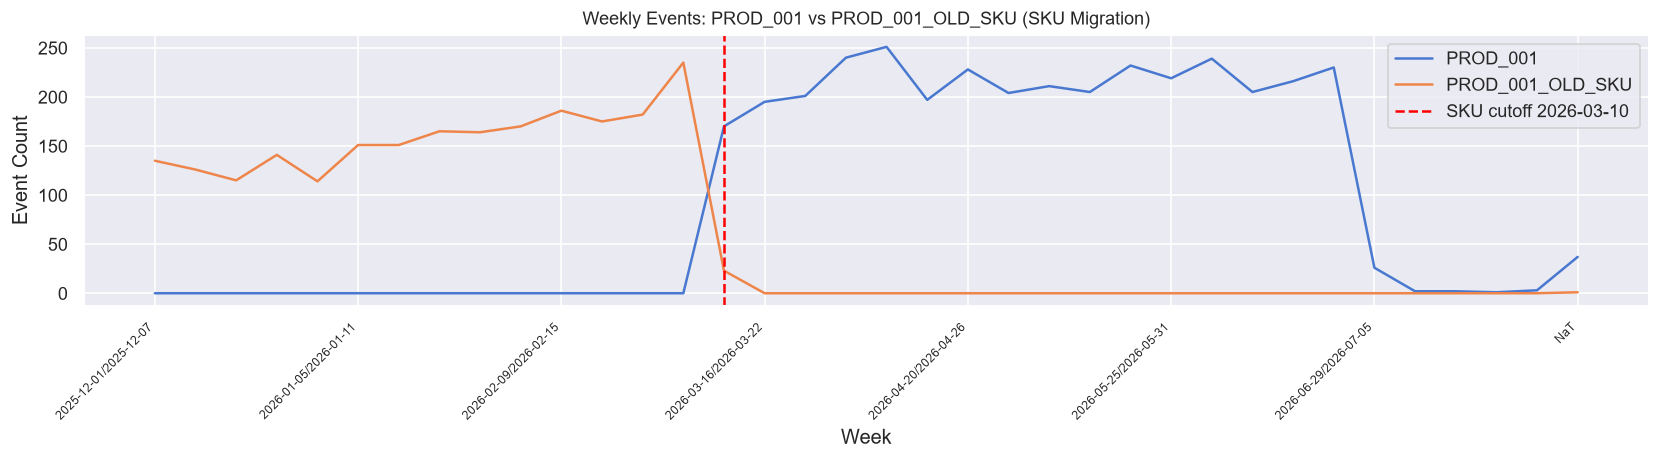

In [ ]:
# chaos 4.2 SKU migration (identity crisis) 
# PROD_001 was renamed to PROD_001_OLD_SKU for events before 2026-03-10
# analytics sees two products where one exists — time series breaks at cutoff

cutoff = pd.Timestamp("2026-03-10")

prod_001_old  = df[df["product_id"] == "PROD_001_OLD_SKU"]
prod_001_new  = df[df["product_id"] == "PROD_001"]

print(f"PROD_001_OLD_SKU events : {len(prod_001_old):,}")
print(f"PROD_001 events : {len(prod_001_new):,}")
print()
print(f"PROD_001_OLD_SKU date range : {prod_001_old['event_timestamp'].min().date()} to {prod_001_old['event_timestamp'].max().date()}")
print(f"PROD_001 date range : {prod_001_new['event_timestamp'].min().date()} to {prod_001_new['event_timestamp'].max().date()}")

# visualise weekly event count for both SKUs to show the migration cutoff
df_sku = df[df["product_id"].isin(["PROD_001", "PROD_001_OLD_SKU"])].copy()
df_sku["week"] = df_sku["event_timestamp"].dt.to_period("W").astype(str)

sku_weekly = df_sku.groupby(["week", "product_id"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
sku_weekly.plot(ax=ax, linewidth=1.5)
# find the index position of the cutoff week directly
cutoff_week_str = str(pd.Period("2026-03-10", freq="W"))
cutoff_idx = sku_weekly.index.tolist().index(cutoff_week_str) if cutoff_week_str in sku_weekly.index else None
if cutoff_idx is not None:
    ax.axvline(x=cutoff_idx, color="red", linestyle="--", linewidth=1.5, label="SKU cutoff 2026-03-10")
ax.set_title("Weekly Events: PROD_001 vs PROD_001_OLD_SKU (SKU Migration)", fontsize=11)
ax.set_xlabel("Week")
ax.set_ylabel("Event Count")
ax.legend()
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

# Silver layer fix:
# df.loc[df["product_id"] == "PROD_001_OLD_SKU", "product_id"] = "PROD_001"
# Add a flag column: df["sku_migrated"] = df["product_id_original"] == "PROD_001_OLD_SKU" 

In [16]:
#  chaos 4.3 fat finger outlier 
units_num = pd.to_numeric(
    df["units_sold"].astype(str).str.replace(" units", "", regex=False),
    errors="coerce"
)

fat_finger_mask = units_num == 999999
print(f"Fat finger rows (units_sold = 999999) : {fat_finger_mask.sum()}")
print(df.loc[fat_finger_mask, ["event_id","node_id","product_id","units_sold","event_timestamp"]].to_string(index=False))
print()

# chaos 4.5  negative stock 
neg_stock_mask = df["stock_on_hand"] < 0
print(f"Negative stock_on_hand rows : {neg_stock_mask.sum()}")
print(df.loc[neg_stock_mask, ["event_id","node_id","product_id","stock_on_hand","event_timestamp"]].head(5).to_string(index=False))
print()

# outlier summary units_sold distribution 
valid_units = units_num[
    (df["event_type"] == "customer_fulfillment") & units_num.notna()
]

p99 = valid_units.quantile(0.99)
p999 = valid_units.quantile(0.999)
upper = valid_units.mean() + 3 * valid_units.std()

print(f"units_sold 99th pct : {p99:.0f}")
print(f"units_sold 99.9th pct : {p999:.0f}")
print(f"units_sold mean+3std : {upper:.0f}")
print(f"Rows above mean+3std : {(valid_units > upper).sum()}")

# Silver layer fix:
# [20] Cap units_sold at mean + 3*std, flag capped rows
# [22] stock_on_hand < 0 -> set to 0, flag as adjustment_error

Fat finger rows (units_sold = 999999) : 2
   event_id   node_id product_id units_sold     event_timestamp
EVT_0230463 DS_BHL_01   PROD_034     999999 2026-04-02 08:39:00
EVT_0359421 DS_NAV_02   PROD_002     999999 2026-05-28 10:41:00

Negative stock_on_hand rows : 10
   event_id   node_id product_id  stock_on_hand     event_timestamp
EVT_0048376 DS_PKS_01        NaN           -173 2025-12-30 23:30:00
EVT_0111883 DS_AND_03        NaN           -143 2026-02-03 06:00:00
EVT_0164215 DS_KOR_01        NaN           -127 2026-03-02 13:00:00
EVT_0169255 DS_VEL_02        NaN           -134 2026-03-04 18:00:00
EVT_0256544 DS_ROH_01        NaN           -157 2026-04-14 13:00:00

units_sold 99th pct : 15
units_sold 99.9th pct : 23
units_sold mean+3std : 8165
Rows above mean+3std : 2


In [17]:
#  chaos 4.6 seasonal demand masking 
# 100 fulfillment rows deleted on spike dates for top-5 nodes
# effect: demand appears lower than reality on New Year, Holi, Baisakhi

spike_dates = pd.to_datetime(["2025-12-31", "2026-03-14", "2026-04-14"]).date

df["event_date"] = df["event_timestamp"].dt.date

spike_mask = df["event_date"].isin(spike_dates)
spike_events = df[spike_mask & (df["event_type"] == "customer_fulfillment")]

print("=== Fulfillment events on spike dates ===")
print(spike_events.groupby("event_date").size().to_string())
print()

# compare against non-spike days in same month to detect suppression
def avg_daily_fulfillments(month_str):
    mask = (
        df["event_timestamp"].dt.to_period("M").astype(str) == month_str
    ) & (df["event_type"] == "customer_fulfillment")
    return df[mask].groupby("event_date").size().mean()

print(f"Avg daily fulfillments Dec 2025 : {avg_daily_fulfillments('2025-12'):.0f}")
print(f"Fulfillments on 2025-12-31 : {len(df[(df['event_date']==date(2025,12,31)) & (df['event_type']=='customer_fulfillment')]):,}")
print()
print(f"Avg daily fulfillments Mar 2026 : {avg_daily_fulfillments('2026-03'):.0f}")
print(f"Fulfillments on 2026-03-14 (Holi) : {len(df[(df['event_date']==date(2026,3,14)) & (df['event_type']=='customer_fulfillment')]):,}")

# Silver layer fix:
# Cross-reference with config.yaml demand_spike_events
# Days that show <70% of average fulfillments AND match a known spike date
# → flag as potentially masked demand, do not use for baseline demand modelling

=== Fulfillment events on spike dates ===
event_date
2025-12-31    1184
2026-03-14    1246
2026-04-14    1315

Avg daily fulfillments Dec 2025 : 1210
Fulfillments on 2025-12-31 : 1,184

Avg daily fulfillments Mar 2026 : 1299
Fulfillments on 2026-03-14 (Holi) : 1,246


## EDA Summary: Anomaly Counts and Silver Layer Fix Map

In [ ]:
# full anomaly summary table 
# this table is the input specification for the Silver layer cleaning notebook

summary = pd.DataFrame([
    # temporal
    {"chaos_id": "01", "category": "Temporal", "name": "UTC/IST Drift", "detected": 85360, "silver_fix": "Add 5h30m to timestamps where device_id in dead_rtc_scanners set"},
    {"chaos_id": "02", "category": "Temporal", "name": "Timezone Double-Conversion", "detected": 3481, "silver_fix": "Subtract 11h from old firmware rows outside valid range"},
    {"chaos_id": "03", "category": "Temporal", "name": "Batch Heartbeat", "detected": 1393,  "silver_fix": "Flag rows at exactly 23:59:59 from slow scanner nodes"},
    {"chaos_id": "04", "category": "Temporal", "name": "Future Timestamp", "detected": 4318,  "silver_fix": "Flag event_timestamp > SIM_END as invalid"},
    {"chaos_id": "05", "category": "Temporal", "name": "Midnight Rollover",  "detected": 10795, "silver_fix": "Flag rows where time component is exactly 00:00:00 from non transfer events"},
    {"chaos_id": "06", "category": "Temporal", "name": "Processing Lag Smear", "detected": 2597,  "silver_fix": "Flag lag == 155.5, impute with node median lag"},
    # structural
    {"chaos_id": "07", "category": "Structural", "name": "Schema Poisoning (Unit Suffix)", "detected": 50, "silver_fix": "str.replace(' units','') then pd.to_numeric"},
    {"chaos_id": "08", "category": "Structural", "name": "Decimal Separator", "detected": 895, "silver_fix": "Round processing_lag_hours to 2 decimal places in silver_02_schema_sanitisation.sql"},
    {"chaos_id": "09", "category": "Structural", "name": "City Corruption", "detected": 3, "silver_fix": "Never use nodes_chaotic.city, join from clean dim_node"},
    {"chaos_id": "10", "category": "Structural", "name": "Null RTO Reason", "detected": 20, "silver_fix": "Impute 'unknown' where units_rto > 0 and rto_reason is null"},
    {"chaos_id": "11", "category": "Structural", "name": "UoM Mismatch", "detected": 5, "silver_fix": "units_transferred * 24 for email_manual supplier inbound transfers"},
    # operational
    {"chaos_id": "12", "category": "Operational", "name": "Ghost Inventory", "detected": 20, "silver_fix": "Flag fulfillment rows where units_sold > stock_on_hand + 500"},
    {"chaos_id": "13", "category": "Operational", "name": "Duplicate Echoes (Exact)", "detected": 100, "silver_fix": "drop_duplicates(subset=[node_id,product_id,units_sold,event_timestamp])"},
    {"chaos_id": "14", "category": "Operational", "name": "Duplicate Echoes (Sub second)", "detected": 50, "silver_fix": "Drop rows where ts_diff from previous same node/product < 1 second"},
    {"chaos_id": "15", "category": "Operational", "name": "Node Blackout", "detected": 69, "silver_fix": "Flag missing (date, node_id) pairs, forward fill stock_on_hand"},
    {"chaos_id": "16", "category": "Operational", "name": "Reverse Logistics Void", "detected": 15, "silver_fix": "Flag rto_return where units_rto >= 100 and stock_on_hand <= 5"},
    {"chaos_id": "17", "category": "Operational", "name": "Lateral Transfer Orphan", "detected": 5, "silver_fix": "Exclude MISSING_SOURCE transfers from stock balance calculations"},
    # market
    {"chaos_id": "18", "category": "Market", "name": "GST Math Drift", "detected": 4474,  "silver_fix": "Divide units_sold by 1.18 for SFTP_XML supplier products; flag rows"},
    {"chaos_id": "19", "category": "Market", "name": "SKU Migration", "detected": 2234,  "silver_fix": "Replace PROD_001_OLD_SKU with PROD_001, add sku_migrated flag column"},
    {"chaos_id": "20", "category": "Market", "name": "Fat Finger Outlier", "detected": 2, "silver_fix": "Cap at mean + 3*std, flag as fat_finger_anomaly"},
    {"chaos_id": "21", "category": "Market" ,"name": "Price Drift — Rounding", "detected": 7202,"silver_fix": "processing_lag_hours already fixed by comma; dot replacement in chaos 08"},    
    {"chaos_id": "22", "category": "Market", "name": "Negative Stock", "detected": 10, "silver_fix": "Set stock_on_hand = 0 where negative, flag as stock_adjustment_error"},
    {"chaos_id": "23", "category": "Market", "name": "Seasonal Demand Masking", "detected": 100, "silver_fix": "Flag spike dates with <70% average demand; exclude from baseline demand models"},
    # LAD
    {"chaos_id": "24", "category": "LAD", "name": "Late-Arriving Event", "detected": 2408, "silver_fix": "Flag processing_lag_hours > 48; partition separately in Gold layer"},
    {"chaos_id": "25", "category": "LAD", "name": "Out-of-Order Sequence", "detected": 10, "silver_fix": "Sort by event_timestamp within (node_id, product_id) before aggregation"},
])

print("=== PhantomProof EDA, Anomaly Summary ===")
print(summary.to_string(index=False))
print()
print(f"Total anomalous rows touched : {summary['detected'].sum():,}")
print(f"Total events in dataset : {len(df):,}")
print(f"Anomaly rate : {summary['detected'].sum() / len(df) * 100:.1f}%")

# save the summary for Silver layer reference
summary.to_csv("eda_anomaly_summary.csv", index=False)
print("\nSaved: eda_anomaly_summary.csv, use this as Silver layer specification")

=== PhantomProof EDA, Anomaly Summary ===
chaos_id    category                           name  detected                                                                     silver_fix
      01    Temporal                  UTC/IST Drift     85360               Add 5h30m to timestamps where device_id in dead_rtc_scanners set
      02    Temporal     Timezone Double-Conversion      3481                        Subtract 11h from old firmware rows outside valid range
      03    Temporal                Batch Heartbeat      1393                          Flag rows at exactly 23:59:59 from slow scanner nodes
      04    Temporal               Future Timestamp      4318                                      Flag event_timestamp > SIM_END as invalid
      05    Temporal              Midnight Rollover     10795    Flag rows where time component is exactly 00:00:00 from non transfer events
      06    Temporal           Processing Lag Smear      2597                                 Flag lag == 155.5,